In [1]:
import joblib, pandas as pd
from utils.narrative_profiles_utils import plot_shap_diagnostics
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from pathlib import Path

c:\Users\nasta\anaconda3\envs\ssp_metamodel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.1_narrative_profiles.pkl"
MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)

e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\utils\narrative_profiles_utils.py:84: RuntimeWarning: overflow encountered in expm1
  y_pred = np.expm1(y_pred)


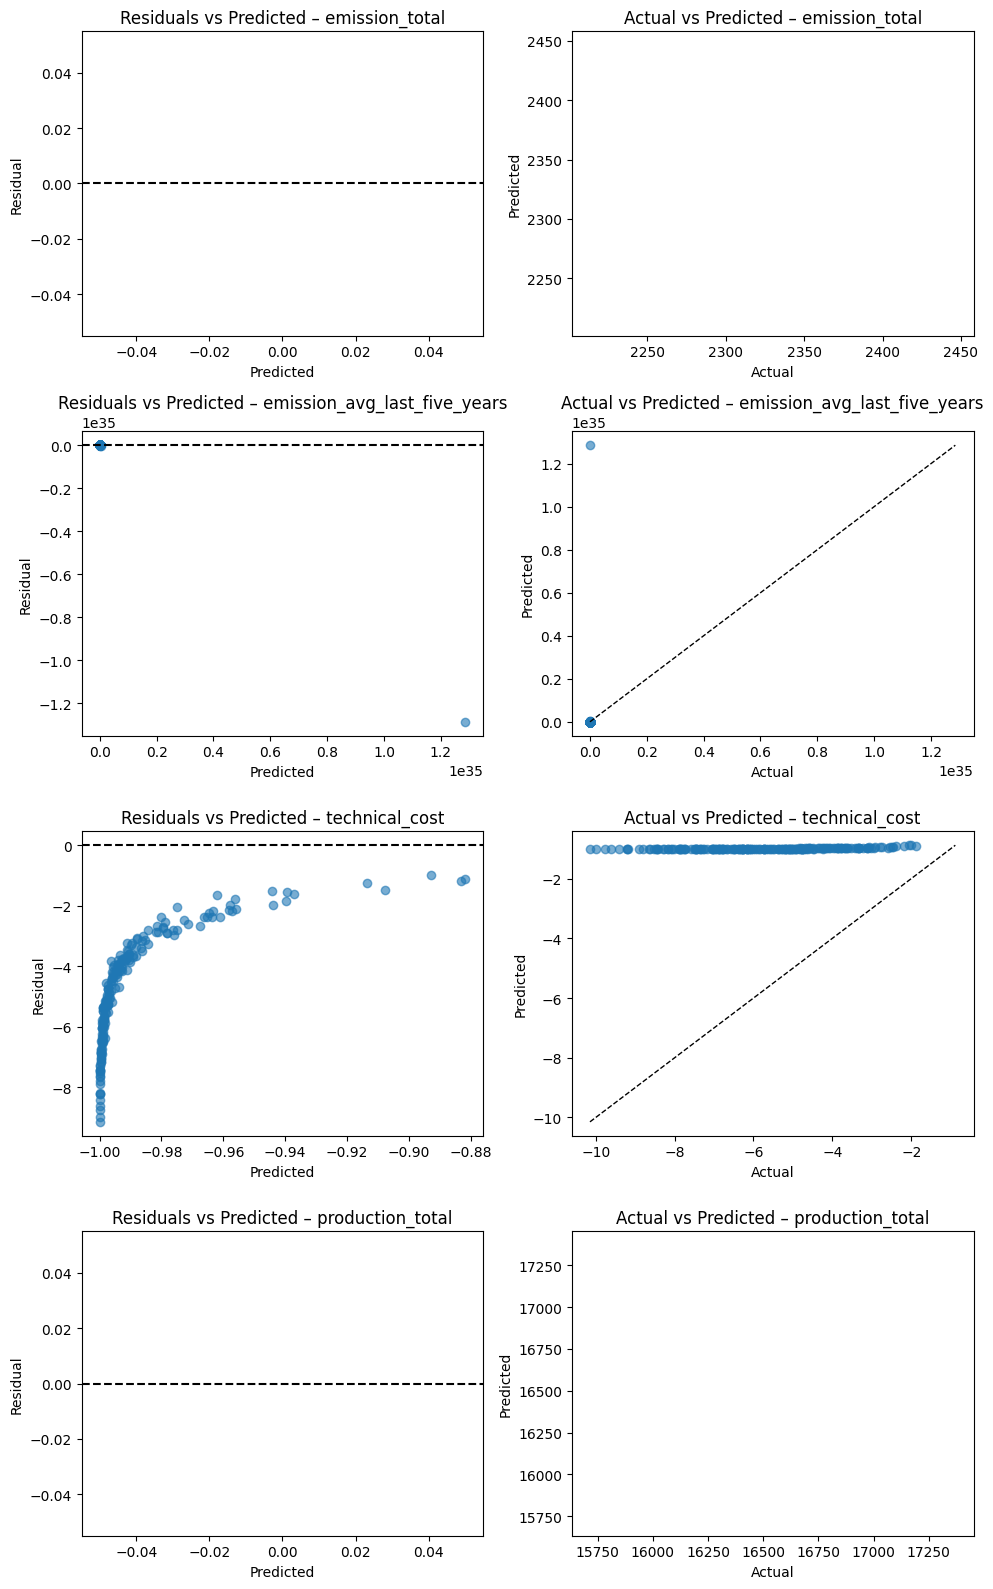

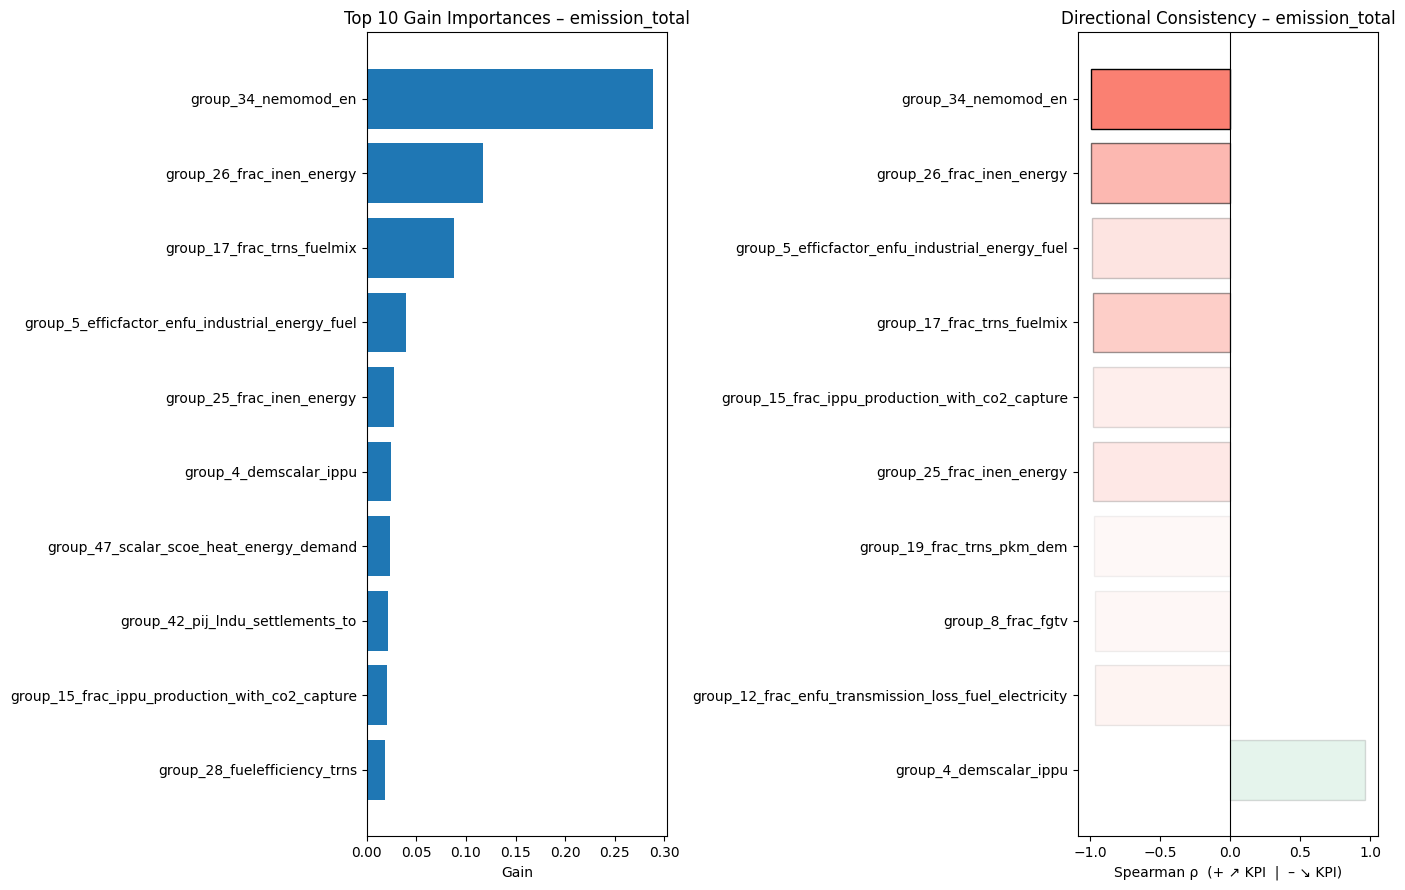

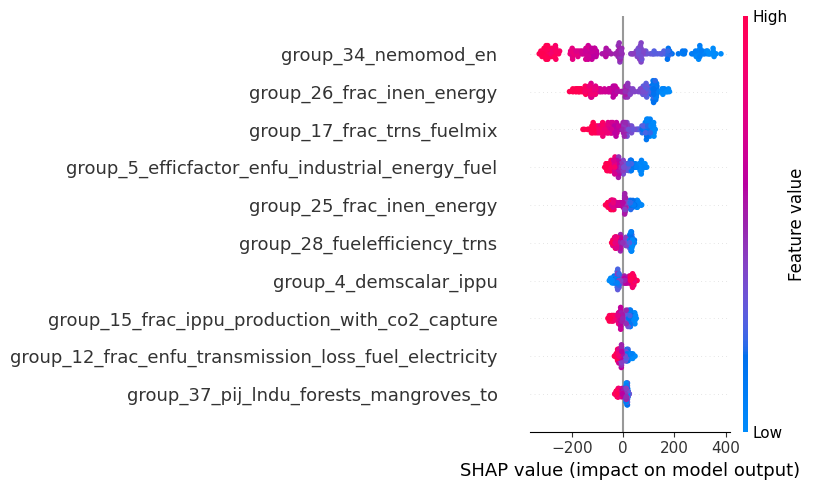

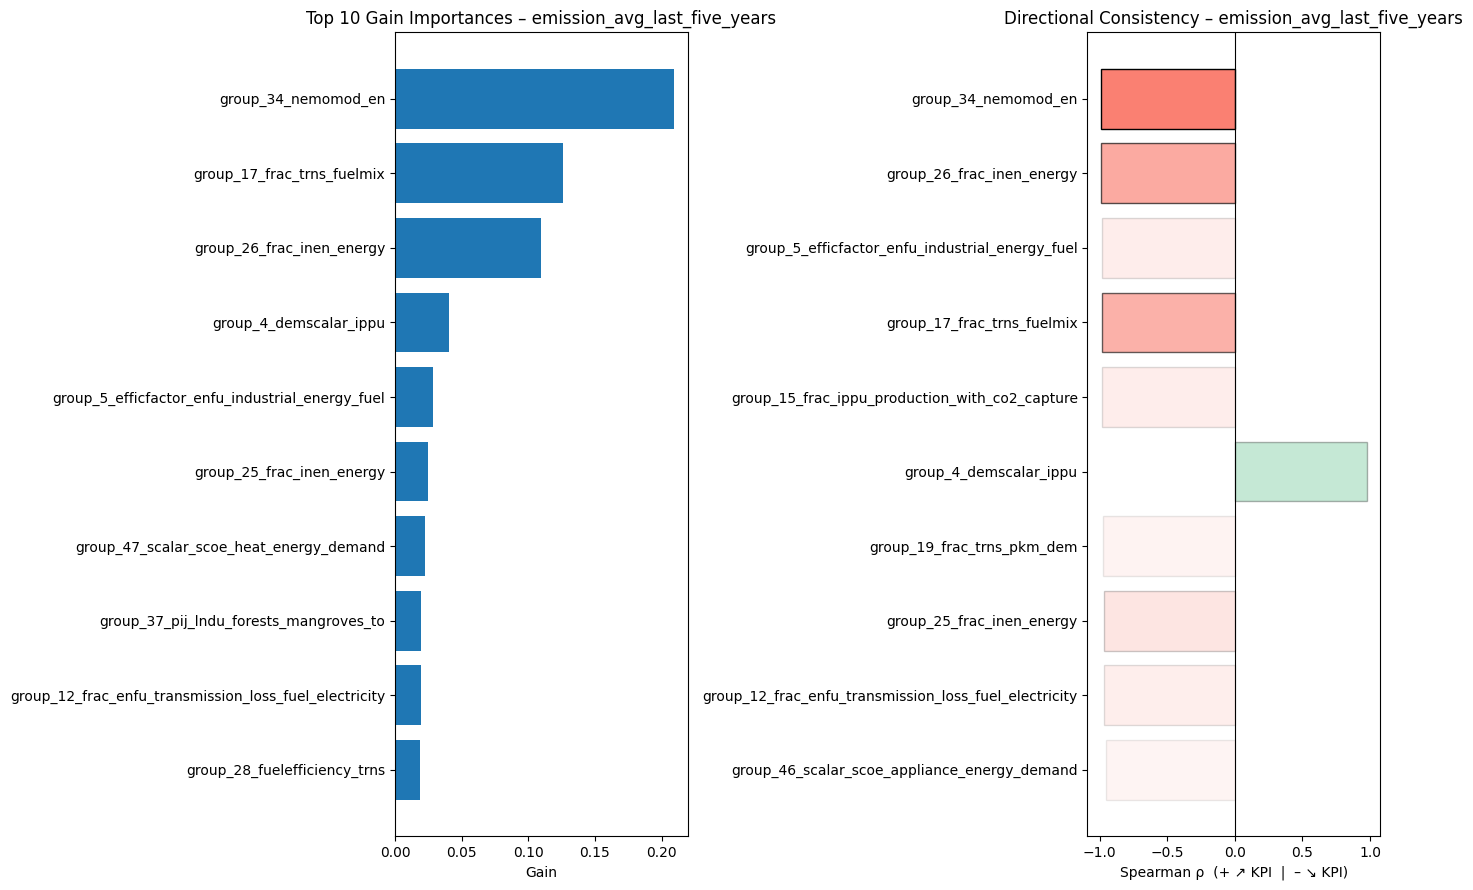

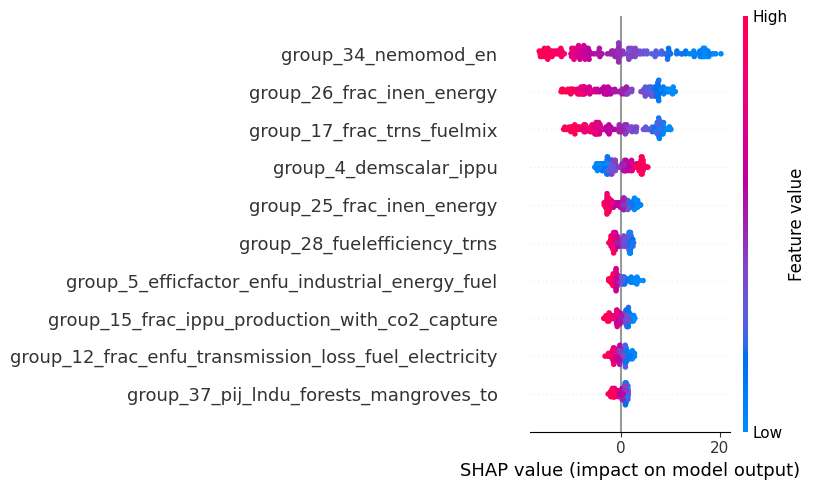

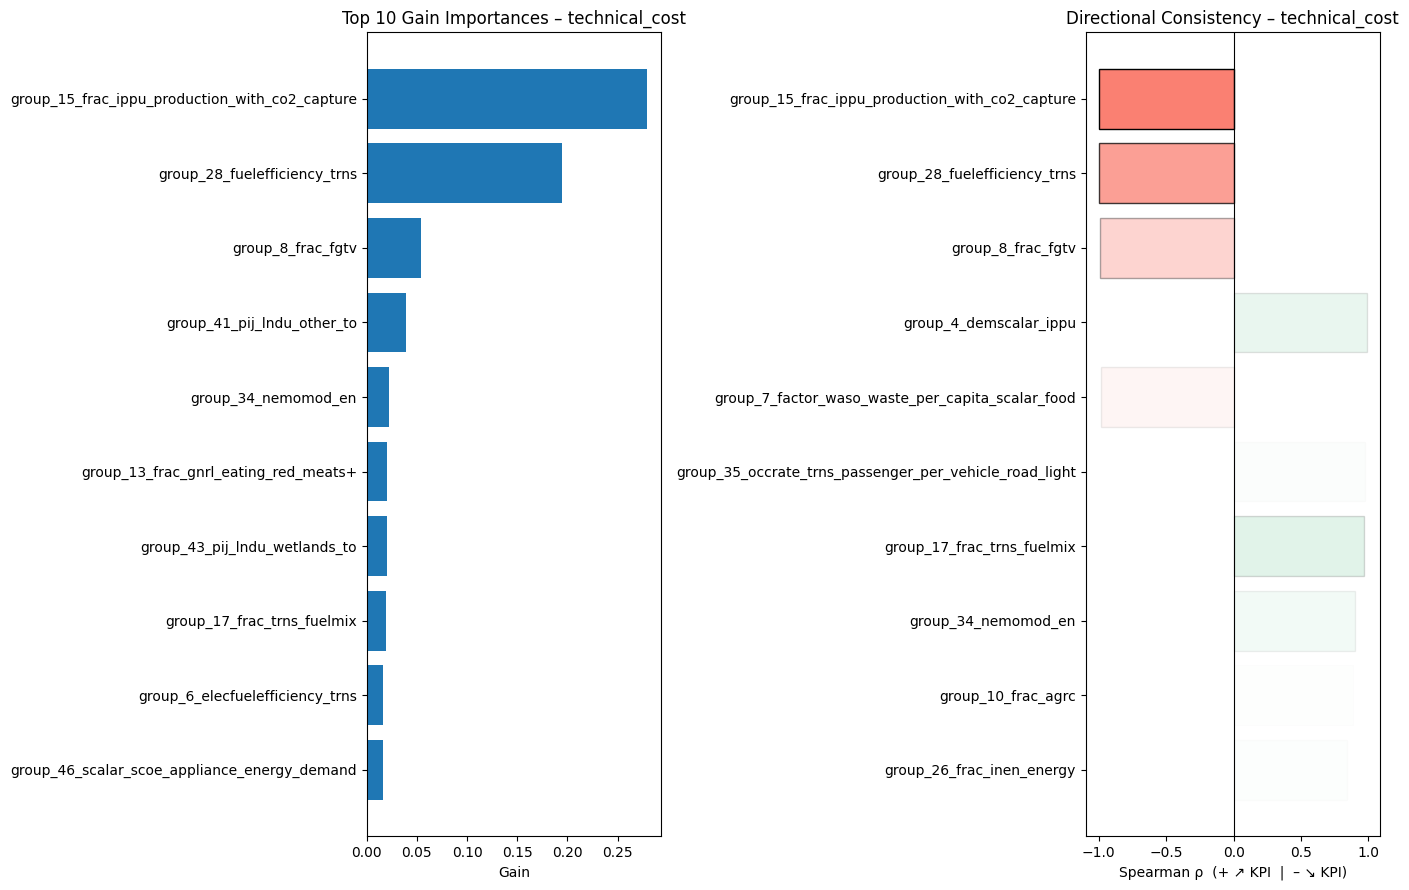

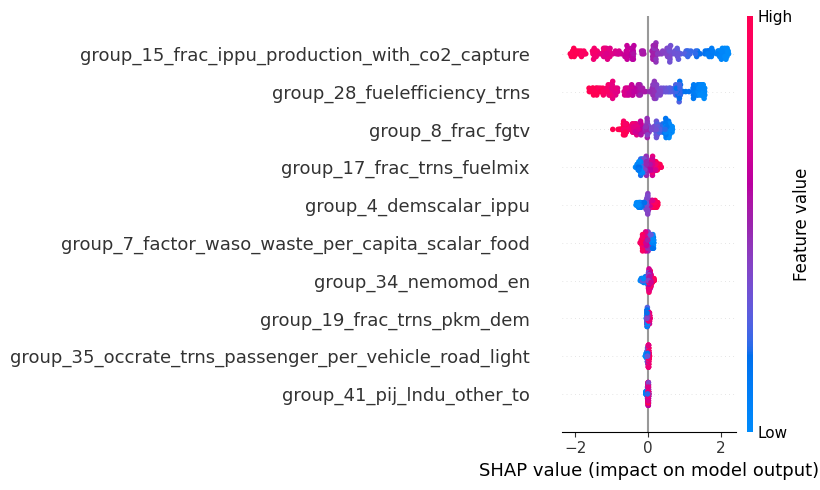

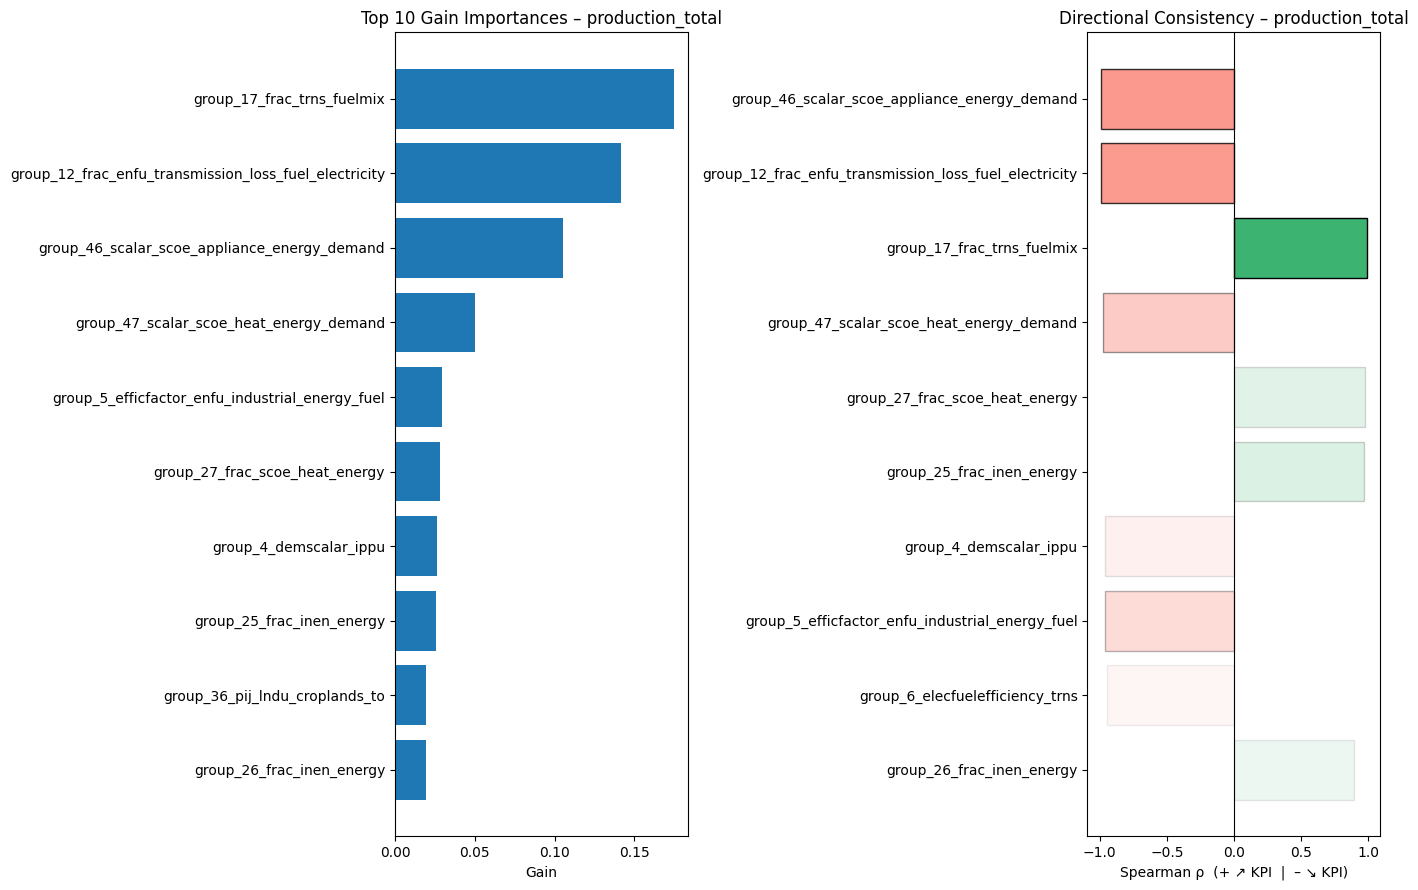

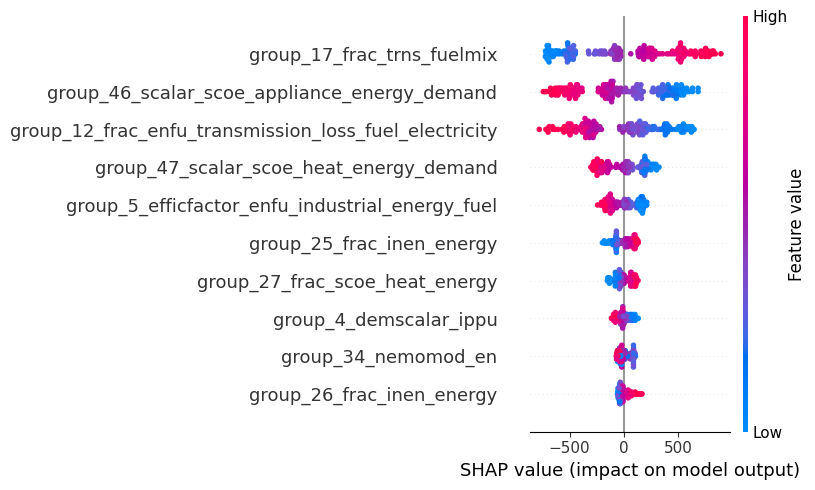

In [3]:


# load artefacts
pipeline = joblib.load(MODEL_PATH)   # your trained Pipeline
X_test   = pd.read_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.1_narrative_profiles_X_test.parquet")
y_test   = pd.read_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.1_narrative_profiles_y_test.parquet")
targets  = ["emission_total", "emission_avg_last_five_years", "technical_cost", "production_total"]                   # order matches training

# fire up the visuals
plot_shap_diagnostics(
    pipeline,
    X_test,
    y_test,
    targets,
    log_transform=True,   # set True if targets were log-transformed during fit
    top_n=10              # number of features to show in bar/beeswarm charts
)
